# Kausalität – Korrelation, Kausalität und Regression

> Quelle: [numiqo.de](https://numiqo.de/tutorial/kausalit%C3%A4t)

**Kausalität** bedeutet eine eindeutige **Ursache-Wirkungs-Beziehung**:
Handlung A verursacht Ergebnis B.

**Drei Konzepte im Überblick:**

| Konzept | Aussage | Methode |
|---|---|---|
| **Korrelation** | Gibt es einen Zusammenhang? | Pearson, Spearman, ... |
| **Kausalität** | Verursacht A das B? | Theorie + Zeitreihe + Experiment |
| **Regression** | Wie stark sagt A das B vorher? | Lineare/logistische Regression |

**Voraussetzungen für Kausalität (beide müssen erfüllt sein):**
1. **Signifikante Korrelation** zwischen A und B
2. **Entweder:** Zeitliche Reihenfolge (A vor B erhoben) **oder** theoretisch begründete Richtung

> **Merksatz:** Korrelation ≠ Kausalität. Aber ohne Korrelation gibt es keine Kausalität.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Korrelation vs. Kausalität: Vier Szenarien

Eine Korrelation kann auf sehr verschiedene Weisen entstehen:

1. **A → B**: A verursacht B (echte Kausalität)
2. **B → A**: Umgekehrte Kausalität
3. **Z → A, Z → B**: Drittvariable erzeugt Scheinkorrelation
4. **Zufall**: Keine echte Beziehung (Zufallskorrelation bei kleinem n)

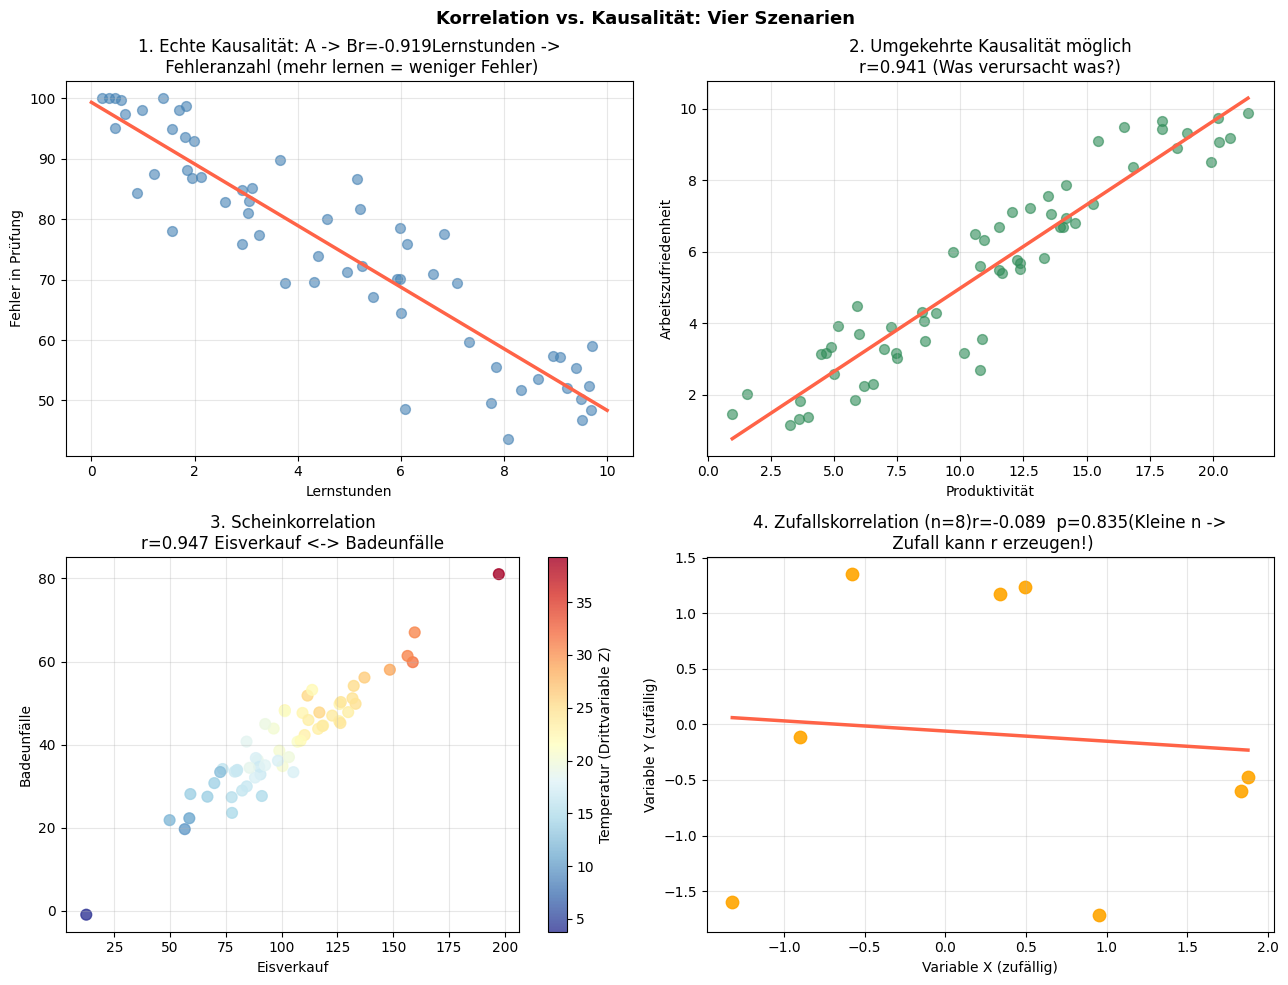

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Korrelation vs. Kausalität: Vier Szenarien", fontsize=13,
             fontweight="bold")
np.random.seed(42)
n_k = 60

# 1. Echte Kausalität: Lernstunden -> Prüfungsnote
lernstunden = np.random.uniform(0, 10, n_k)
note = 100 - 5 * lernstunden + np.random.normal(0, 8, n_k)
note = np.clip(note, 0, 100)
r1, _ = pearsonr(lernstunden, note)
axes[0,0].scatter(lernstunden, note, color="steelblue", alpha=0.6, s=50)
m1, b1 = np.polyfit(lernstunden, note, 1)
x1 = np.linspace(0, 10, 100)
axes[0,0].plot(x1, m1*x1+b1, color="tomato", linewidth=2.5)
axes[0,0].set_title("1. Echte Kausalität: A -> Br=" + str(round(r1, 3)) +
                    "Lernstunden ->\n Fehleranzahl (mehr lernen = weniger Fehler)")
axes[0,0].set_xlabel("Lernstunden")
axes[0,0].set_ylabel("Fehler in Prüfung")
axes[0,0].grid(alpha=0.3)

# 2. Umgekehrte Kausalität
zufriedenheit = np.random.uniform(1, 10, n_k)
produktivitaet = 2 * zufriedenheit + np.random.normal(0, 2, n_k)
r2, _ = pearsonr(produktivitaet, zufriedenheit)
axes[0,1].scatter(produktivitaet, zufriedenheit, color="seagreen", alpha=0.6, s=50)
m2, b2 = np.polyfit(produktivitaet, zufriedenheit, 1)
x2 = np.linspace(produktivitaet.min(), produktivitaet.max(), 100)
axes[0,1].plot(x2, m2*x2+b2, color="tomato", linewidth=2.5)
axes[0,1].set_title("2. Umgekehrte Kausalität möglich\nr=" + str(round(r2, 3)) + " (Was verursacht was?)")
axes[0,1].set_xlabel("Produktivität")
axes[0,1].set_ylabel("Arbeitszufriedenheit")
axes[0,1].grid(alpha=0.3)

# 3. Scheinkorrelation durch Drittvariable
temperatur = np.random.normal(20, 5, n_k)
eis = 5 * temperatur + np.random.normal(0, 8, n_k)
unfaelle = 2 * temperatur + np.random.normal(0, 4, n_k)
r3, _ = pearsonr(eis, unfaelle)
sc3 = axes[1,0].scatter(eis, unfaelle, c=temperatur, cmap="RdYlBu_r",
                        s=60, alpha=0.8)
plt.colorbar(sc3, ax=axes[1,0], label="Temperatur (Drittvariable Z)")
m3, b3 = np.polyfit(eis, unfaelle, 1)
x3 = np.linspace(eis.min(), eis.max(), 100)
axes[1,0].set_title("3. Scheinkorrelation\nr=" + str(round(r3, 3)) + " Eisverkauf <-> Badeunfälle")
axes[1,0].set_xlabel("Eisverkauf")
axes[1,0].set_ylabel("Badeunfälle")
axes[1,0].grid(alpha=0.3)

# 4. Zufallskorrelation
x_z = np.random.normal(0, 1, 8)
y_z = np.random.normal(0, 1, 8)
r4, p4 = pearsonr(x_z, y_z)
axes[1,1].scatter(x_z, y_z, color="orange", s=80, alpha=0.9)
m4, b4 = np.polyfit(x_z, y_z, 1)
x4 = np.linspace(x_z.min(), x_z.max(), 100)
axes[1,1].plot(x4, m4*x4+b4, color="tomato", linewidth=2.5)
axes[1,1].set_title("4. Zufallskorrelation (n=8)r=" + str(round(r4, 3)) +
                    "  p=" + str(round(p4, 3)) +
                    "(Kleine n ->\n Zufall kann r erzeugen!)")
axes[1,1].set_xlabel("Variable X (zufällig)")
axes[1,1].set_ylabel("Variable Y (zufällig)")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Voraussetzungen für Kausalität (numiqo)

**Bedingung 1:** Signifikante Korrelation (notwendig, aber nicht hinreichend)

**Bedingung 2a:** Zeitliche Reihenfolge – A wurde vor B erhoben

**Bedingung 2b:** Theoretisch begründete Richtung

**Beispiel numiqo:** Alter beim ersten Satz → Schulerfolg
- Korrelation vorhanden? → prüfen
- Zeitliche Reihenfolge: Sprache *vor* Schulerfolg → Kausalität plausibel

Beispiel: Sprache und Schulerfolg

Bedingung 1: Signifikante Korrelation?
  r=-0.571  p=0.0
  -> JA: Signifikante Korrelation vorhanden

Bedingung 2: Zeitliche Reihenfolge oder Theorie?
  -> JA: Sprachalter wird VOR dem Schulerfolg gemessen
  -> Kausalität plausibel: frühes Sprechen -> besserer Schulerfolg

Fazit: Kausale Beziehung annehmbar!
Nächster Schritt: Regression (Vorhersage)


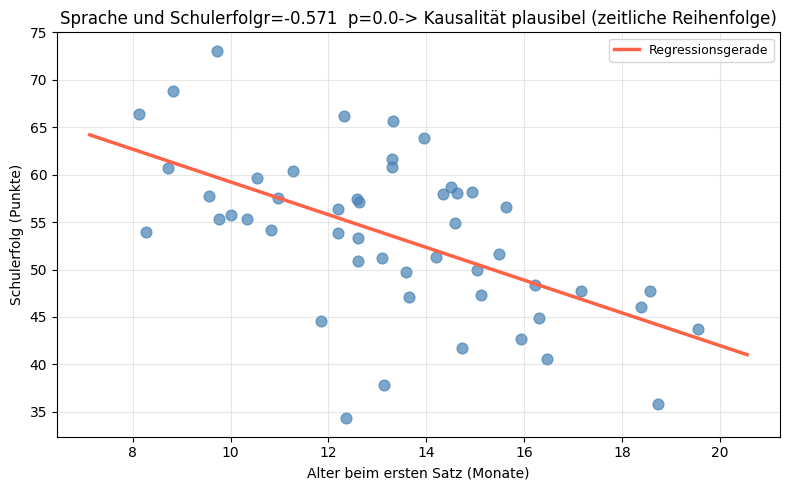

In [3]:
# Voraussetzungen-Prüfung demonstrieren
np.random.seed(42)
n_bsp = 50

# Beispiel: Alter beim ersten Satz (Monate) -> Schulerfolg
alter_sprache = np.random.normal(14, 3, n_bsp)   # Monate
schulerfolg   = -2 * alter_sprache + 80 + np.random.normal(0, 8, n_bsp)

r_bsp, p_bsp = pearsonr(alter_sprache, schulerfolg)

print("Beispiel: Sprache und Schulerfolg")
print()
print("Bedingung 1: Signifikante Korrelation?")
print("  r=" + str(round(r_bsp, 3)) + "  p=" + str(round(p_bsp, 4)))
if p_bsp < 0.05:
    print("  -> JA: Signifikante Korrelation vorhanden")
else:
    print("  -> NEIN: Keine signifikante Korrelation")
print()
print("Bedingung 2: Zeitliche Reihenfolge oder Theorie?")
print("  -> JA: Sprachalter wird VOR dem Schulerfolg gemessen")
print("  -> Kausalität plausibel: frühes Sprechen -> besserer Schulerfolg")
print()
print("Fazit: Kausale Beziehung annehmbar!")
print("Nächster Schritt: Regression (Vorhersage)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(alter_sprache, schulerfolg, color="steelblue", alpha=0.7, s=60)
m_b, b_b = np.polyfit(alter_sprache, schulerfolg, 1)
x_b = np.linspace(alter_sprache.min()-1, alter_sprache.max()+1, 100)
ax.plot(x_b, m_b*x_b+b_b, color="tomato", linewidth=2.5,
        label="Regressionsgerade")
ax.set_title("Sprache und Schulerfolgr=" + str(round(r_bsp, 3)) +
             "  p=" + str(round(p_bsp, 4)) +
             "-> Kausalität plausibel (zeitliche Reihenfolge)")
ax.set_xlabel("Alter beim ersten Satz (Monate)")
ax.set_ylabel("Schulerfolg (Punkte)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Weg von Korrelation zu Regression

```
Schritt 1: Korrelation prüfen
  -> Pearson/Spearman r, p-Wert
  -> Ist der Zusammenhang signifikant?

Schritt 2: Kausalität begründen
  -> Zeitliche Reihenfolge ODER Theorie
  -> Wer ist UV (Prädiktor), wer ist AV (Kriterium)?

Schritt 3: Regression berechnen
  -> Y = b0 + b1*X
  -> Vorhersage von Y durch X
  -> Nur sinnvoll wenn kausale Richtung klar!
```

> Die Regression **setzt** eine kausale Richtung voraus –
> sie kann Kausalität **nicht beweisen**!

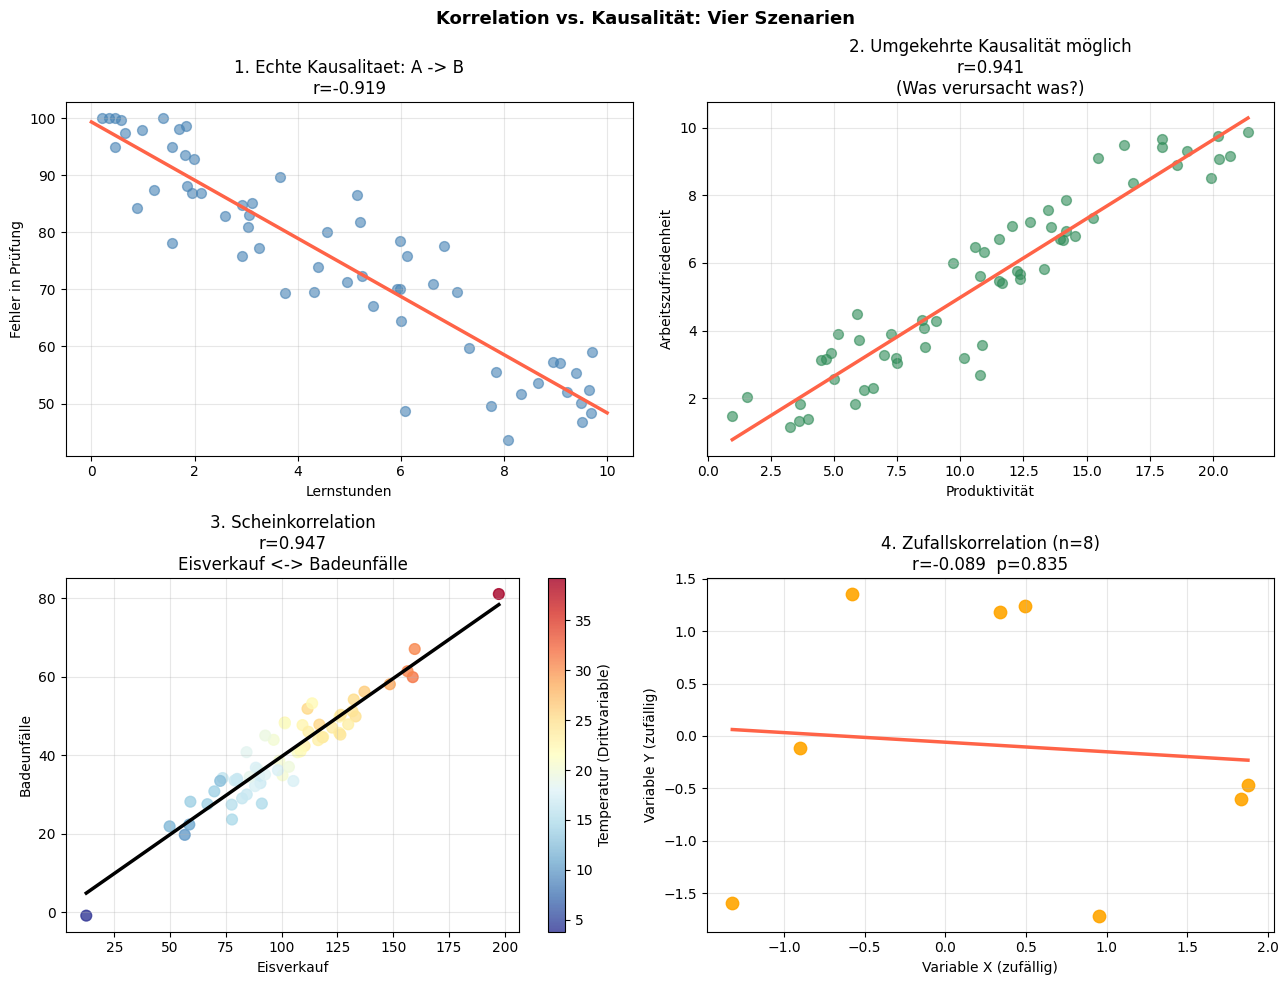

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Korrelation vs. Kausalität: Vier Szenarien", fontsize=13, fontweight="bold")
np.random.seed(42)
n_k = 60

# 1. Echte Kausalität
lernstunden = np.random.uniform(0, 10, n_k)
note = 100 - 5 * lernstunden + np.random.normal(0, 8, n_k)
note = np.clip(note, 0, 100)
r1, _ = pearsonr(lernstunden, note)
axes[0,0].scatter(lernstunden, note, color="steelblue", alpha=0.6, s=50)
m1, b1 = np.polyfit(lernstunden, note, 1)
x1 = np.linspace(0, 10, 100)
axes[0,0].plot(x1, m1*x1+b1, color="tomato", linewidth=2.5)
axes[0,0].set_title("1. Echte Kausalitaet: A -> B\nr=" + str(round(r1, 3)))
axes[0,0].set_xlabel("Lernstunden")
axes[0,0].set_ylabel("Fehler in Prüfung")
axes[0,0].grid(alpha=0.3)

# 2. Umgekehrte Kausalität
zufriedenheit = np.random.uniform(1, 10, n_k)
produktivitaet = 2 * zufriedenheit + np.random.normal(0, 2, n_k)
r2, _ = pearsonr(produktivitaet, zufriedenheit)
axes[0,1].scatter(produktivitaet, zufriedenheit, color="seagreen", alpha=0.6, s=50)
m2, b2 = np.polyfit(produktivitaet, zufriedenheit, 1)
x2 = np.linspace(produktivitaet.min(), produktivitaet.max(), 100)
axes[0,1].plot(x2, m2*x2+b2, color="tomato", linewidth=2.5)
axes[0,1].set_title("2. Umgekehrte Kausalität möglich\nr=" + str(round(r2, 3)) + "\n(Was verursacht was?)")
axes[0,1].set_xlabel("Produktivität")
axes[0,1].set_ylabel("Arbeitszufriedenheit")
axes[0,1].grid(alpha=0.3)

# 3. Scheinkorrelation durch Drittvariable
temperatur = np.random.normal(20, 5, n_k)
eis = 5 * temperatur + np.random.normal(0, 8, n_k)
unfaelle = 2 * temperatur + np.random.normal(0, 4, n_k)
r3, _ = pearsonr(eis, unfaelle)
sc3 = axes[1,0].scatter(eis, unfaelle, c=temperatur, cmap="RdYlBu_r", s=60, alpha=0.8)
plt.colorbar(sc3, ax=axes[1,0], label="Temperatur (Drittvariable)")
m3, b3 = np.polyfit(eis, unfaelle, 1)
x3 = np.linspace(eis.min(), eis.max(), 100)
axes[1,0].plot(x3, m3*x3+b3, color="black", linewidth=2.5)
axes[1,0].set_title("3. Scheinkorrelation\nr=" + str(round(r3, 3)) + "\nEisverkauf <-> Badeunfälle")
axes[1,0].set_xlabel("Eisverkauf")
axes[1,0].set_ylabel("Badeunfälle")
axes[1,0].grid(alpha=0.3)

# 4. Zufallskorrelation
x_z = np.random.normal(0, 1, 8)
y_z = np.random.normal(0, 1, 8)
r4, p4 = pearsonr(x_z, y_z)
axes[1,1].scatter(x_z, y_z, color="orange", s=80, alpha=0.9)
m4, b4 = np.polyfit(x_z, y_z, 1)
x4 = np.linspace(x_z.min(), x_z.max(), 100)
axes[1,1].plot(x4, m4*x4+b4, color="tomato", linewidth=2.5)
axes[1,1].set_title("4. Zufallskorrelation (n=8)\nr=" + str(round(r4, 3)) + "  p=" + str(round(p4, 3)))
axes[1,1].set_xlabel("Variable X (zufällig)")
axes[1,1].set_ylabel("Variable Y (zufällig)")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Zusammenfassung

```
Kausalität – Übersicht
│
├── DEFINITION
│   Eindeutige Ursache-Wirkungs-Beziehung: A verursacht B
│
├── VORAUSSETZUNGEN (beide nötig)
│   1. Signifikante Korrelation zwischen A und B
│   2a. Zeitliche Reihenfolge: A vor B erhoben
│   ODER
│   2b. Theoretisch begründete Wirkungsrichtung
│
├── KORRELATION != KAUSALITÄT (4 Gründe)
│   A -> B:     Echte Kausalität
│   B -> A:     Umgekehrte Kausalität
│   Z -> A,B:   Scheinkorrelation (Drittvariable)
│   Zufall:     Zufallskorrelation (besonders bei kleinem n)
│
├── WEG ZUR REGRESSION
│   Schritt 1: Korrelation prüfen (r, p-Wert)
│   Schritt 2: Kausalität begründen (Theorie / Zeit)
│   Schritt 3: Regression berechnen (Vorhersage)
│   -> Regression SETZT kausale Richtung voraus
│   -> Regression kann Kausalität NICHT beweisen!
│
├── numiqo-BEISPIEL
│   Sprachalter -> Schulerfolg
│   Zeitliche Reihenfolge klar -> Kausalität plausibel
│
└── MERKSATZ
    Ohne Korrelation keine Kausalität.
    Mit Korrelation noch keine Kausalität.
    Kausalität = Korrelation + Theorie/Zeit + kein Gegenargument
```

---
Quelle: [numiqo.de/tutorial/kausalitaet](https://numiqo.de/tutorial/kausalit%C3%A4t)